In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data , columns=data.feature_names)
y = pd.DataFrame(data.target , columns=['target'])

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [5]:
model = DecisionTreeClassifier()
model.fit(X_train , y_train)
y_pred = model.predict(X_test)

In [6]:
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy Score :" , accuracy)

Accuracy Score : 0.9385964912280702


# Hyperparameter Tunning

In [15]:
param_grid = {
    "criterion" : ['gini' , 'entropy'],
    "max_depth" : [3 , 5 , 7 , 10 , 15 , None],
    "min_samples_split" : [25 , 50 , 100],
    "min_samples_leaf" : [1 , 2 , 5 , 10]
}

grid = GridSearchCV(estimator=model , param_grid=param_grid , cv = 10 , scoring='accuracy')
grid.fit(X_train , y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, 15, None],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [25, 50, 100]},
             scoring='accuracy')

In [16]:
y_pred = grid.predict(X_test)
accuracy = accuracy_score(y_test , y_pred)
print("Accuracy Score :" , accuracy)

Accuracy Score : 0.9649122807017544


In [18]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 3,
 'min_samples_leaf': 5,
 'min_samples_split': 25}

In [19]:
grid.best_estimator_

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       min_samples_split=25)

In [20]:
grid.best_score_

np.float64(0.9341062801932368)

In [21]:
grid.best_index_

np.int64(78)

In [22]:
grid.cv

10

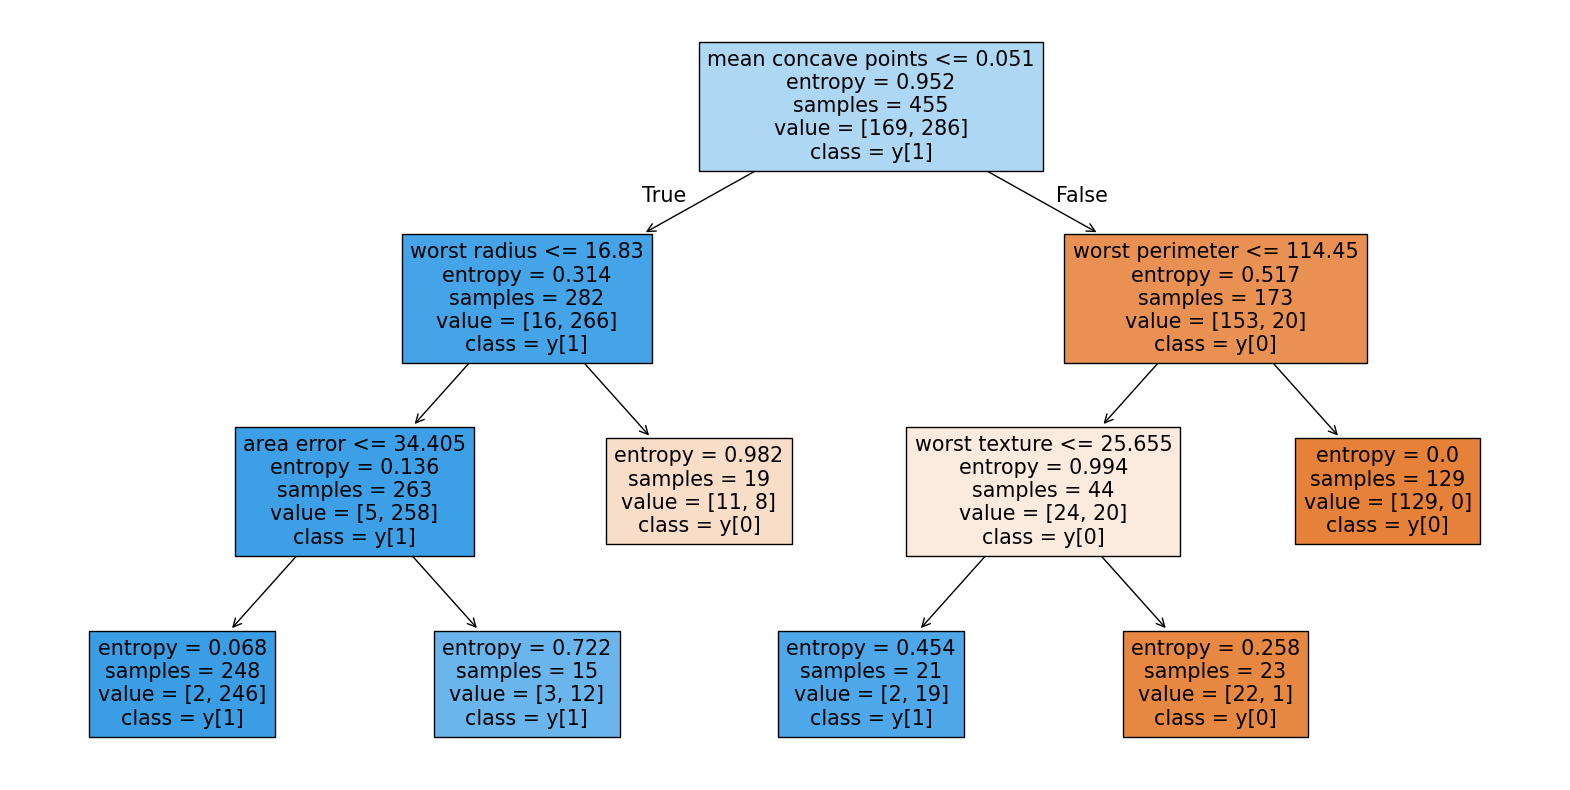

In [28]:
plt.figure(figsize=(20,10))
plot_tree(
    grid.best_estimator_,
    feature_names=X_train.columns,
    class_names=True,
    filled=True
)
plt.show()